In [10]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


In [13]:
# Load the dataset


logging.info("Loading the dataset.")
data_path = "../data/merged_train_data.parquet"  # Update with your actual file path

# Use read_parquet for .parquet files
try:
    data = pd.read_parquet(data_path)
    logging.info("Dataset loaded successfully. Displaying basic information:")
    print(data.info())
    print(data.head())
except Exception as e:
    logging.error("Error loading the dataset: %s", e)
    raise e


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               986159 non-null   float64
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1017209 non-null  float64
 12  CompetitionOpenSinceMonth  1017209 non-null  float64
 13  CompetitionO

In [15]:
import pandas as pd
import logging

# Setting up logging
logging.basicConfig(level=logging.INFO)

# Convert Date column to datetime format
logging.info("Converting 'Date' column to datetime.")
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Check if the conversion was successful
logging.info("Checking for missing values after Date conversion.")
logging.info(f"Missing values in 'Date': {data['Date'].isnull().sum()}")

# Handle missing values for 'StateHoliday' - you can use the mode (most frequent value) or fill with 0 if it makes sense
logging.info("Filling missing values in 'StateHoliday'.")
data['StateHoliday'] = data['StateHoliday'].fillna(0)

# Handle missing values for 'PromoInterval' - you can fill with 'None' if it makes sense
logging.info("Filling missing values in 'PromoInterval'.")
data['PromoInterval'] = data['PromoInterval'].fillna('None')

# Verify changes
logging.info("Verifying missing values after filling.")
logging.info(f"Missing values in 'StateHoliday': {data['StateHoliday'].isnull().sum()}")
logging.info(f"Missing values in 'PromoInterval': {data['PromoInterval'].isnull().sum()}")


In [16]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Step 1: Extract weekday and weekend information
logging.info("Extracting weekday and weekend information.")
data['Weekday'] = data['Date'].dt.weekday  # Monday=0, Sunday=6
data['Is_Weekend'] = data['Weekday'].isin([5, 6]).astype(int)  # 1 if weekend, 0 otherwise

# Step 2: Generate Days_To_Holiday and Days_After_Holiday
# Note: This part assumes you have a predefined list of holidays, like 'holidays = [pd.Timestamp('YYYY-MM-DD')]'
holidays = pd.to_datetime(['2015-12-25', '2016-01-01', '2016-12-25'])  # example holidays

logging.info("Calculating 'Days_To_Holiday' and 'Days_After_Holiday'.")
data['Days_To_Holiday'] = data['Date'].apply(
    lambda x: min([(holiday - x).days for holiday in holidays if (holiday - x).days > 0], default=np.nan)
)
data['Days_After_Holiday'] = data['Date'].apply(
    lambda x: min([(x - holiday).days for holiday in holidays if (x - holiday).days > 0], default=np.nan)
)

# Step 3: Create features for beginning, mid-month, and end-of-month
logging.info("Creating features for the beginning, mid-month, and end-of-month.")
data['Day_Of_Month'] = data['Date'].dt.day
data['Month'] = data['Date'].dt.month
data['Year'] = data['Date'].dt.year

data['Beginning_Of_Month'] = (data['Day_Of_Month'] <= 7).astype(int)
data['Mid_Month'] = ((data['Day_Of_Month'] > 7) & (data['Day_Of_Month'] <= 14)).astype(int)
data['End_Of_Month'] = (data['Day_Of_Month'] > 14).astype(int)

# Step 4: Apply feature scaling using StandardScaler
logging.info("Scaling numeric features using StandardScaler.")
numeric_features = ['Sales', 'Customers', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 
                    'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear', 'Days_To_Holiday', 
                    'Days_After_Holiday', 'Day_Of_Month', 'Month', 'Year']

scaler = StandardScaler()
data[numeric_features] = scaler.fit_transform(data[numeric_features])

# Verify the first few rows of the preprocessed dataset
logging.info("Displaying the first few rows of the preprocessed dataset.")
print(data.head())



c:\Users\Hp\Music\week4\venv\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\Hp\Music\week4\venv\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\Hp\Music\week4\venv\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


   Store  DayOfWeek       Date     Sales  Customers  Open  Promo  \
0      1          5 2015-07-31 -0.132683  -0.168269     1      1   
1      2          5 2015-07-31  0.075373  -0.017540     1      1   
2      3          5 2015-07-31  0.659800   0.404499     1      1   
3      4          5 2015-07-31  2.135414   1.862258     1      1   
4      5          5 2015-07-31 -0.247231  -0.159656     1      1   

   StateHoliday  SchoolHoliday StoreType  ... Weekday  Is_Weekend  \
0           0.0              1         c  ...       4           0   
1           0.0              1         a  ...       4           0   
2           0.0              1         a  ...       4           0   
3           0.0              1         c  ...       4           0   
4           0.0              1         a  ...       4           0   

   Days_To_Holiday  Days_After_Holiday  Day_Of_Month     Month      Year  \
0        -1.734123                 NaN      1.740766  0.346724  1.502077   
1        -1.734123      

In [22]:
import pandas as pd
import numpy as np
import logging

logging.basicConfig(level=logging.INFO)

# Load the dataset
data_path = "../data/merged_train_data.parquet"  # Update this path accordingly
data = pd.read_parquet(data_path)  # Adjust depending on the file format

# Ensure the dataset is loaded correctly
logging.info(f"Dataset loaded. Shape: {data.shape}")
logging.info(f"Columns: {data.columns.tolist()}")

# Fill missing values if any
data['StateHoliday'].fillna(0, inplace=True)
data['PromoInterval'].fillna('None', inplace=True)

# Convert date columns to datetime type
data['Date'] = pd.to_datetime(data['Date'])

# Feature Engineering: Day of the week, weekend flag
data['Weekday'] = data['Date'].dt.weekday
data['Is_Weekend'] = data['Weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Adding additional temporal features
data['Days_To_Holiday'] = (data['Date'] - pd.to_datetime('2025-12-25')).dt.days  # Example for holidays, modify as needed
data['Days_After_Holiday'] = (pd.to_datetime('2025-12-25') - data['Date']).dt.days

# Extract day, month, and year as features
data['Day_Of_Month'] = data['Date'].dt.day
data['Month'] = data['Date'].dt.month
data['Year'] = data['Date'].dt.year

# Example: StoreType conversion to categorical
data['StoreType'] = data['StoreType'].map({'a': 0, 'b': 1, 'c': 2, 'd': 3})  # Map store types to numerical values

# Check transformed data
logging.info(f"Transformed data preview:\n{data.head()}")


C:\Users\Hp\AppData\Local\Temp\ipykernel_13928\3914496272.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['StateHoliday'].fillna(0, inplace=True)
C:\Users\Hp\AppData\Local\Temp\ipykernel_13928\3914496272.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [24]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns with LabelEncoder
label_encoder = LabelEncoder()

# Convert 'StoreType', 'Assortment', 'PromoInterval' to numeric
data['StoreType'] = label_encoder.fit_transform(data['StoreType'])
data['Assortment'] = label_encoder.fit_transform(data['Assortment'])
data['PromoInterval'] = data['PromoInterval'].fillna('None')  # Fill missing values with 'None' for PromoInterval
data['PromoInterval'] = label_encoder.fit_transform(data['PromoInterval'])

# Ensure the columns are now numeric
logging.info(f"Encoded categorical columns. Preview:\n{data[['StoreType', 'Assortment', 'PromoInterval']].head()}")


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
import numpy as np

# Assuming 'data' is your DataFrame
# Check for non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns
print(f"Non-numeric columns: {non_numeric_columns}")

# Encode non-numeric columns
label_encoders = {}
for col in non_numeric_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))  # Convert to string before encoding
    label_encoders[col] = le

# Ensure all remaining features are numeric
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)  # Handle any NaN values by filling with 0

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R-Squared (R²): {r2}")


Non-numeric columns: Index(['StoreType', 'Assortment', 'PromoInterval'], dtype='object')
R-Squared (R²): 0.9831976298253571


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import logging 


logging.info("MAE")
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


Mean Absolute Error (MAE): 306.9651660127329
Root Mean Squared Error (RMSE): 498.48453107176215


In [9]:
import pandas as pd

# Create predictions_df
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})


In [16]:
import os
error_analysis = predictions_df.copy()
predictions_df['Error'] = predictions_df['Actual'] - predictions_df['Predicted']

error_analysis['Error'] = abs(error_analysis['Actual'] - error_analysis['Predicted'])
error_analysis = error_analysis.sort_values(by='Error', ascending=False)
print(error_analysis.head())

output_folder = 'notebooks/outputs'
os.makedirs(output_folder, exist_ok=True)

# Save predictions
predictions_path = os.path.join(output_folder, 'predictions.csv')
predictions_df.to_csv(predictions_path, index=False)
print(f"Predictions saved to {predictions_path}")

# Save error analysis
error_analysis_path = os.path.join(output_folder, 'error_analysis.csv')
error_analysis.to_csv(error_analysis_path, index=False)
print(f"Error analysis saved to {error_analysis_path}")



        Actual     Predicted         Error
44393    41551  18759.860000  22791.140000
693985   18697   4265.778571  14431.221429
684721   17298   3613.152000  13684.848000
388891    4866  18342.123333  13476.123333
454398   25920  13522.340000  12397.660000
Predictions saved to notebooks/outputs\predictions.csv
Error analysis saved to notebooks/outputs\error_analysis.csv


In [ ]:
import os

# Define the outputs folder path
output_folder = os.path.join('notebooks', 'outputs')

# Create the folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)


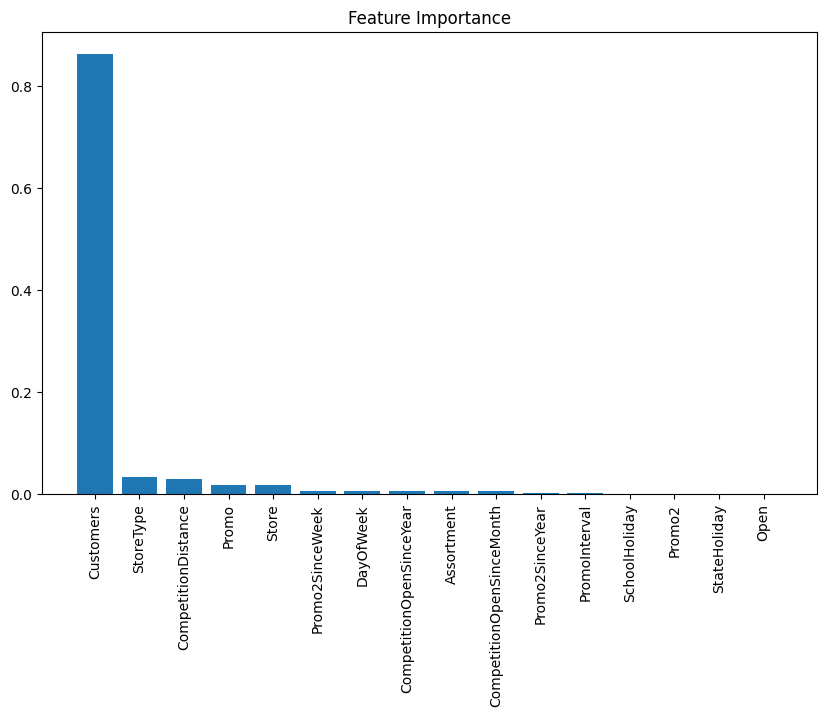

<Figure size 640x480 with 0 Axes>

In [13]:
import matplotlib.pyplot as plt
import logging 


logging.info("feauter importance")
feature_importances = model.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align="center")
plt.xticks(range(len(feature_importances)), X.columns[sorted_indices], rotation=90)
plt.title("Feature Importance")
plt.show()

output_folder = './outputs'
os.makedirs(output_folder, exist_ok=True)
feature_importance_path = os.path.join(output_folder, 'feature_importance.png')
plt.savefig(feature_importance_path)



Plot Details:
Type: Residuals Plot (Scatter plot of Actual vs. Prediction Error)
X-axis Label: Actual Values
Y-axis Label: Prediction Error
Title: Residuals Plot
Residuals plot saved to notebooks/outputs\residuals_plot.png


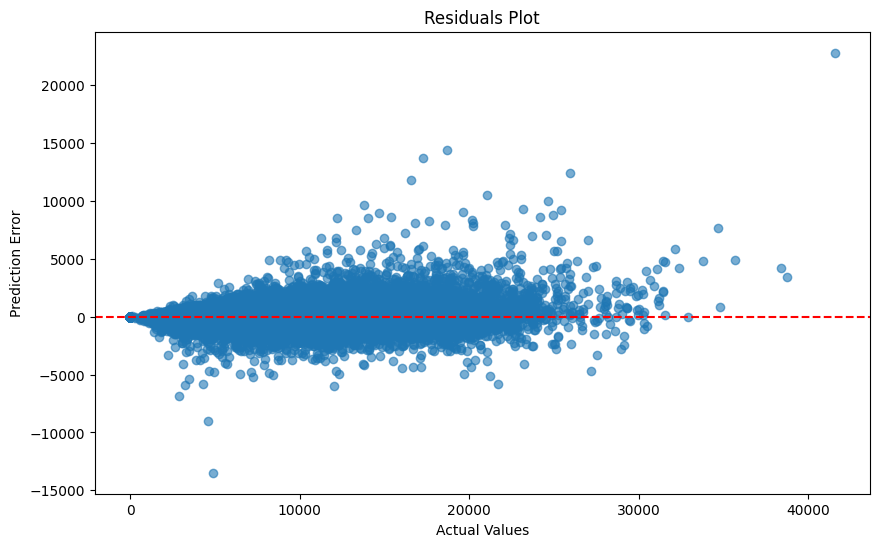

In [18]:
import os
import matplotlib.pyplot as plt

# Residuals Plot
plt.figure(figsize=(10, 6))
plt.scatter(predictions_df['Actual'], predictions_df['Error'], alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Prediction Error')
plt.title('Residuals Plot')

# Log plot details
print("Plot Details:")
print("Type: Residuals Plot (Scatter plot of Actual vs. Prediction Error)")
print(f"X-axis Label: Actual Values")
print(f"Y-axis Label: Prediction Error")
print(f"Title: Residuals Plot")

# Save the plot
residual_plot_path = os.path.join(output_folder, 'residuals_plot.png')
plt.savefig(residual_plot_path)
print(f"Residuals plot saved to {residual_plot_path}")

# Show the plot
plt.show()


In [20]:
print(predictions_df.head())
print(predictions_df.columns)


        Actual  Predicted     Error
76435        0      0.000     0.000
923026    5548   6086.281  -538.281
731180    7467   8130.860  -663.860
790350    3360   3480.183  -120.183
252134   11414   9409.160  2004.840
Index(['Actual', 'Predicted', 'Error'], dtype='object')
